# 第006讲 读表清洗与可视化

这份Notebook从原始CSV逐步建立探索结果，不需要访问网络。先阅读每段预期，再运行后面的代码。所有房屋、日期、片区和价格均为课程合成，不构成市场资料。

**完成目标**：核对16条记录、14次挂牌、12套房屋；用证据处理重复与缺失；拦住错误合并；报告带分母的摘要；画图时说明范围；演示只用训练资料学习填补值。没有模型拟合或性能比较。

建议第一次按Shift+Enter从上到下执行。最后使用Restart Kernel and Run All检查没有依赖旧变量。

## 1 检查环境与文件

预期列出版本，四个输入文件都存在。此处只显示文件名，不输出个人目录。读不到文件时先检查Notebook是否与data文件夹同层。

In [1]:
from pathlib import Path
import sys
import json
import os
os.environ.setdefault("MPLCONFIGDIR", str(Path(".mpl_cache").resolve()))
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Image as NotebookImage
from io import BytesIO

ROOT = Path.cwd()
RAW = ROOT / "data" / "raw"
print({"python": sys.version.split()[0], "pandas": pd.__version__,
       "numpy": np.__version__, "matplotlib": matplotlib.__version__})
for filename in ["listings.csv", "district_candidates.csv", "district_registry.csv", "split_manifest.csv"]:
    assert (RAW / filename).is_file(), f"缺少输入文件：{filename}"
print("四个原始CSV文件均存在")

{'python': '3.12.14', 'pandas': '2.2.3', 'numpy': '2.3.5', 'matplotlib': '3.10.8'}
四个原始CSV文件均存在


## 2 保留原文读表

dtype="string"暂时保留字符形式，keep_default_na=False让我们看见原始缺失标记。预期16行6列。head只看开头，所以也看tail。

In [2]:
raw = pd.read_csv(RAW / "listings.csv", dtype="string", keep_default_na=False, encoding="utf-8")
print("原始形状", raw.shape)
assert raw.shape == (16, 6)
display(raw.head())
display(raw.tail())
print("L014原始面积", repr(raw.loc[raw.event_id.eq("L014"), "area_sqm"].iloc[0]))
display(raw.dtypes)

原始形状 (16, 6)


,event_id,property_id,listed_at,district_code,area_sqm,list_price_wan
0,L001,H01,2026-01-02,N,50,100
1,L002,H02,2026-01-03,N,60,120
2,L003,H03,2026-01-04,S,80,160
3,L004,H04,2026-01-05,S,,180
4,L005,H05,2026-01-06,E,100,200


,event_id,property_id,listed_at,district_code,area_sqm,list_price_wan
11,L012,H12,2026-02-05,X,300,600
12,L013,H01,2026-01-20,N,50,110
13,L014,H02,2026-01-21,N,60,118
14,L003,H03,2026-01-04,S,80,160
15,L009,H09,2026-02-02,N,120,240


L014原始面积 ' 60 '


event_id          string[python]
property_id       string[python]
listed_at         string[python]
district_code     string[python]
area_sqm          string[python]
list_price_wan    string[python]
dtype: object

## 3 一列数和一列表

观察两种括号返回的类型与形状。原始面积现在还是字符串，暂时不要直接求均值。

In [3]:
one_series = raw["area_sqm"]
one_table = raw[["area_sqm"]]
print(type(one_series).__name__, one_series.shape)
print(type(one_table).__name__, one_table.shape)
assert one_series.shape == (16,)
assert one_table.shape == (16, 1)
display(raw.loc[raw["event_id"].eq("L001"), ["event_id", "area_sqm"]])

Series (16,)
DataFrame (16, 1)


,event_id,area_sqm
0,L001,50


## 4 确认完整复制

先保存原始六列，再加入CSV行号。预期移出L003与L009的复制，来源行16与17。来源行号不同不应阻碍判重。

In [4]:
original_columns = raw.columns.tolist()
work = raw.copy()
work["source_csv_line"] = np.arange(2, len(raw) + 2)
duplicate_mask = work.duplicated(subset=original_columns, keep="first")
removed_rows = work.loc[duplicate_mask].copy()
display(removed_rows)
assert removed_rows["source_csv_line"].tolist() == [16, 17]
clean = work.loc[~duplicate_mask].copy()
assert len(clean) == 14
assert clean["event_id"].is_unique
print("整理后事件数", len(clean), "不同房屋数", clean.property_id.nunique())

,event_id,property_id,listed_at,district_code,area_sqm,list_price_wan,source_csv_line
14,L003,H03,2026-01-04,S,80,160,16
15,L009,H09,2026-02-02,N,120,240,17


整理后事件数 14 不同房屋数 12


## 5 保留真正复挂牌

H01的两次挂牌与H02的两次挂牌仍保留。这里的当前文件顺序并非严格日期顺序。

In [5]:
display(clean.loc[clean["property_id"].isin(["H01", "H02"])])
assert clean.property_id.value_counts().loc[["H01", "H02"]].tolist() == [2, 2]
print("复挂牌L013、L014保留")

,event_id,property_id,listed_at,district_code,area_sqm,list_price_wan,source_csv_line
0,L001,H01,2026-01-02,N,50,100,2
1,L002,H02,2026-01-03,N,60,120,3
12,L013,H01,2026-01-20,N,50,110,14
13,L014,H02,2026-01-21,N,60,118,15


复挂牌L013、L014保留


## 6 逐步转换字段

去首尾空格；把声明过的空白与“未知”标记为缺失；其余文本必须能转换。未知数字文本会报错。原始raw没有被覆盖。

In [6]:
clean["district_code"] = clean["district_code"].str.strip()
area_text = clean["area_sqm"].str.strip()
known_missing = area_text.isin(["", "未知"])
clean["area_sqm"] = pd.to_numeric(area_text.mask(known_missing), errors="raise").astype("Float64")
clean["list_price_wan"] = pd.to_numeric(clean["list_price_wan"], errors="raise").astype("Float64")
clean["listed_at"] = pd.to_datetime(clean["listed_at"], format="%Y-%m-%d", errors="raise")
clean = clean.reset_index(drop=True)
display(clean.dtypes)
display(clean.loc[clean.area_sqm.isna(), ["event_id", "area_sqm", "list_price_wan"]])
assert clean.loc[clean.area_sqm.isna(), "event_id"].tolist() == ["L004", "L010"]
assert clean.loc[clean.area_sqm.notna(), "area_sqm"].gt(0).all()

event_id           string[python]
property_id        string[python]
listed_at          datetime64[ns]
district_code      string[python]
area_sqm                  Float64
list_price_wan            Float64
source_csv_line             int64
dtype: object

,event_id,area_sqm,list_price_wan
3,L004,<NA>,180.0
9,L010,<NA>,260.0


## 7 标签定位与位置定位

降序排序后第一位置是最高挂牌价事件L012；按标签取L001仍是它本身。筛选N片区且挂牌价至少120，应得到L002与L009。

In [7]:
by_event = clean.set_index("event_id", verify_integrity=True)
sorted_events = by_event.sort_values("list_price_wan", ascending=False)
print("降序第一位置", sorted_events.iloc[0].name)
print("固定L001挂牌价", sorted_events.loc["L001", "list_price_wan"])
chosen = clean.loc[(clean.district_code.eq("N")) & (clean.list_price_wan >= 120), ["event_id", "list_price_wan"]]
display(chosen)
assert chosen.event_id.tolist() == ["L002", "L009"]

降序第一位置 L012
固定L001挂牌价 100.0


,event_id,list_price_wan
1,L002,120.0
8,L009,240.0


## 8 Series运算按标签对齐

价格显示顺序与面积相反，但相除时仍按L001、L002对应。两个单位价格均为2万元每平方米。这个例子不把顺序不同误当成身份不同。

In [8]:
areas = pd.Series([50, 60], index=["L001", "L002"])
prices = pd.Series([120, 100], index=["L002", "L001"])
unit_prices = prices / areas
display(unit_prices)
assert unit_prices.to_dict() == {"L001": 2.0, "L002": 2.0}

L001    2.0
L002    2.0
dtype: float64

## 9 缺失分母与填零反例

面积已观测均值除以12，缺失比例除以14。填零只是一个反例，不修改clean。

In [9]:
print("事件数", len(clean))
print("面积有效数", clean.area_sqm.count())
print("面积缺失数", clean.area_sqm.isna().sum())
print("价格有效数", clean.list_price_wan.count())
print("面积缺失比例", clean.area_sqm.isna().mean())
print("已观测面积均值", clean.area_sqm.mean())
print("错误填零后的均值", clean.area_sqm.fillna(0).mean())
assert np.isclose(clean.area_sqm.sum(), 1220)
assert np.isclose(clean.area_sqm.mean(), 1220/12)
assert clean.area_sqm.isna().sum() == 2

事件数 14
面积有效数 12
面积缺失数 2
价格有效数 14
面积缺失比例 0.14285714285714285
已观测面积均值 101.66666666666667
错误填零后的均值 87.14285714285714


## 10 合并前检查右键

候选表中N有两个冲突条目。请先预测总行数：五条N各匹配两次，再加其他九条事件，应为19。

In [10]:
candidates = pd.read_csv(RAW / "district_candidates.csv", dtype={"district_code": "string"})
registry = pd.read_csv(RAW / "district_registry.csv", dtype={"district_code": "string"})
conflicts = candidates.loc[candidates.duplicated("district_code", keep=False)]
display(conflicts)
unsafe = clean.merge(candidates, on="district_code", how="left")
print("故意无约束合并行数", len(unsafe))
print("错误合并均价", unsafe.list_price_wan.mean())
assert len(unsafe) == 19
assert np.isclose(unsafe.list_price_wan.mean(), 3576/19)

,district_code,district_name,distance_km,source_id
0,N,北片区,1.2,A
1,N,北片区,1.8,B


故意无约束合并行数 19
错误合并均价 188.21052631578948


## 11 让基数检查拦住错误

此格预期捕获MergeError。捕获仅用于教学展示，不能把错误忽略后继续把unsafe当作干净表。

In [11]:
cardinality_rejected = False
try:
    clean.merge(candidates, on="district_code", how="left", validate="many_to_one")
except pd.errors.MergeError:
    cardinality_rejected = True
    print("预期检查通过：右表N不唯一，many_to_one拒绝合并")
assert cardinality_rejected

预期检查通过：右表N不唯一，many_to_one拒绝合并


## 12 使用确认登记册并保留未匹配

登记册确认N采用A版本。这是题目给出的依据，并非任意选第一行。left应保留14次事件，其中L012没有右条目。

In [12]:
assert registry.district_code.is_unique
assert clean.district_code.notna().all()
merged = clean.merge(registry, on="district_code", how="left", validate="many_to_one", indicator=True)
assert len(merged) == 14
assert merged.event_id.is_unique
display(merged["_merge"].value_counts())
display(merged.loc[merged["_merge"].eq("left_only"), ["event_id", "district_code", "district_name"]])
assert merged.loc[merged["_merge"].eq("left_only"), "event_id"].tolist() == ["L012"]

_merge
both          13
left_only      1
right_only     0
Name: count, dtype: int64

,event_id,district_code,district_name
11,L012,X,NaN


## 13 inner与join各自做了什么

inner会排除没有登记条目的L012。join以右表索引查找，也必须验证多对一。

In [13]:
inner = clean.merge(registry, on="district_code", how="inner", validate="many_to_one")
print("正确left均价", merged.list_price_wan.mean())
print("inner行数与均价", len(inner), inner.list_price_wan.mean())
assert len(inner) == 13
assert np.isclose(inner.list_price_wan.mean(), 176)
joined = clean.join(registry.set_index("district_code", verify_integrity=True),
                    on="district_code", how="left", validate="many_to_one")
assert len(joined) == 14
assert joined.event_id.tolist() == clean.event_id.tolist()
print("join检查通过，未匹配距离数", joined.distance_km.isna().sum())

正确left均价 206.28571428571428
inner行数与均价 13 176.0
join检查通过，未匹配距离数 1


## 14 分组计数与聚合

size计行，count计该列非缺失值。S的面积均值80只由1个观测支持。

In [14]:
group_summary = merged.groupby("district_code", dropna=False).agg(
    event_count=("event_id", "size"),
    area_count=("area_sqm", "count"),
    price_count=("list_price_wan", "count"),
    mean_area_sqm=("area_sqm", "mean"),
    mean_price_wan=("list_price_wan", "mean"),
)
group_summary["area_missing_count"] = group_summary.event_count - group_summary.area_count
group_summary["area_missing_fraction"] = group_summary.area_missing_count / group_summary.event_count
display(group_summary)
assert group_summary.event_count.sum() == 14
assert group_summary.area_count.sum() == 12
assert np.isclose(group_summary.loc["S", "area_missing_fraction"], 2/3)

,event_count,area_count,price_count,mean_area_sqm,mean_price_wan,area_missing_count,area_missing_fraction
district_code,,,,,,,
E,3,3,3,100.0,200.0,0,0.0
N,5,5,5,68.0,137.6,0,0.0
S,3,1,3,80.0,200.0,2,0.666667
W,2,2,2,100.0,200.0,0,0.0
X,1,1,1,300.0,600.0,0,0.0


## 15 不同权重会回答不同问题

直接平均五个片区均值是片区等权；十四次挂牌平均是事件等权。两者数值不同不表示计算器故障。

In [15]:
equal_district_mean = group_summary.mean_price_wan.mean()
equal_event_mean = (group_summary.mean_price_wan * group_summary.event_count).sum() / group_summary.event_count.sum()
print("片区等权均值", equal_district_mean)
print("事件等权均值", equal_event_mean)
assert np.isclose(equal_district_mean, 267.52)
assert np.isclose(equal_event_mean, 2888/14)

片区等权均值 267.52
事件等权均值 206.28571428571428


## 16 分位数与手算逐项比对

规则：先排序，目标位置h=(n−1)q，再在相邻值之间线性插值。这里没有绘制概率模型。

In [16]:
hand_values = pd.Series([50, 60, 100, 130])
hand_quantiles = hand_values.quantile([.25, .5, .75], interpolation="linear")
display(hand_quantiles)
assert np.allclose(hand_quantiles.to_numpy(), [57.5, 80, 107.5])
print("排序挂牌价", clean.list_price_wan.sort_values().tolist())
price_quantiles = clean.list_price_wan.quantile([0, .25, .5, .75, 1], interpolation="linear")
display(price_quantiles)
assert np.allclose(price_quantiles.to_numpy(dtype=float), [100,125,180,235,600])

0.25     57.5
0.50     80.0
0.75    107.5
dtype: float64

排序挂牌价 [100.0, 110.0, 118.0, 120.0, 140.0, 160.0, 180.0, 180.0, 200.0, 220.0, 240.0, 260.0, 260.0, 600.0]


0.00    100.0
0.25    125.0
0.50    180.0
0.75    235.0
1.00    600.0
Name: list_price_wan, dtype: Float64

## 17 先核对每个箱的计数

面积12个观测。80属于第二箱，最右边界320属于最后一箱。箱范围必须覆盖全部准备描述的观测。

In [17]:
area_values = clean.area_sqm.dropna().to_numpy(dtype=float)
edges = [40,80,120,160,200,240,280,320]
counts, used_edges = np.histogram(area_values, bins=edges)
print("细箱计数", counts.tolist())
print("宽箱计数", np.histogram(area_values, bins=[40,180,320])[0].tolist())
assert counts.tolist() == [5,4,2,0,0,0,1]
assert counts.sum() == clean.area_sqm.count() == 12

细箱计数 [5, 4, 2, 0, 0, 0, 1]
宽箱计数 [11, 1]


## 18 两种箱宽画同一批数据

英文标签避免依赖本机中文字体。两个图纵轴都是计数，样本相同；图形差别不是数据变化。

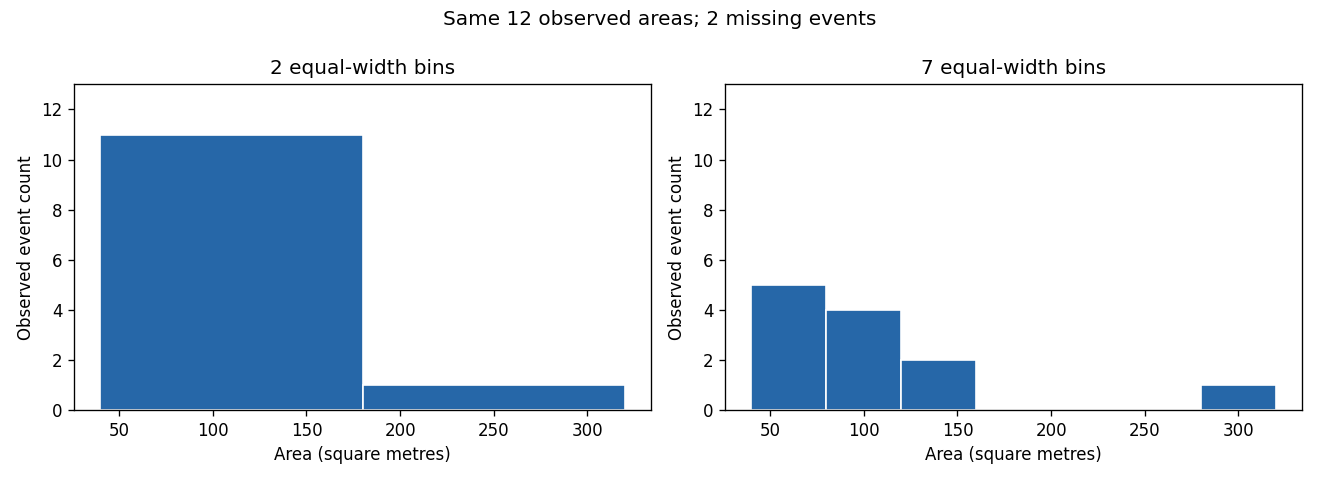

In [18]:
fig, axes = plt.subplots(1,2,figsize=(11,4))
for ax, bins, title in [(axes[0],[40,180,320],"2 equal-width bins"), (axes[1],edges,"7 equal-width bins")]:
    ax.hist(area_values, bins=bins, color="#2667A8", edgecolor="white")
    ax.set(xlabel="Area (square metres)", ylabel="Observed event count", title=title, ylim=(0,13))
fig.suptitle("Same 12 observed areas; 2 missing events")
fig.tight_layout()
image_buffer = BytesIO()
fig.savefig(image_buffer, format="png", dpi=120)
display(NotebookImage(data=image_buffer.getvalue()))
plt.close(fig)

## 19 散点图的范围与缺席记录

每点是一条面积、价格均已知的挂牌。全图必须保留L012；局部放大要说明范围外记录。图只展示合成关联。

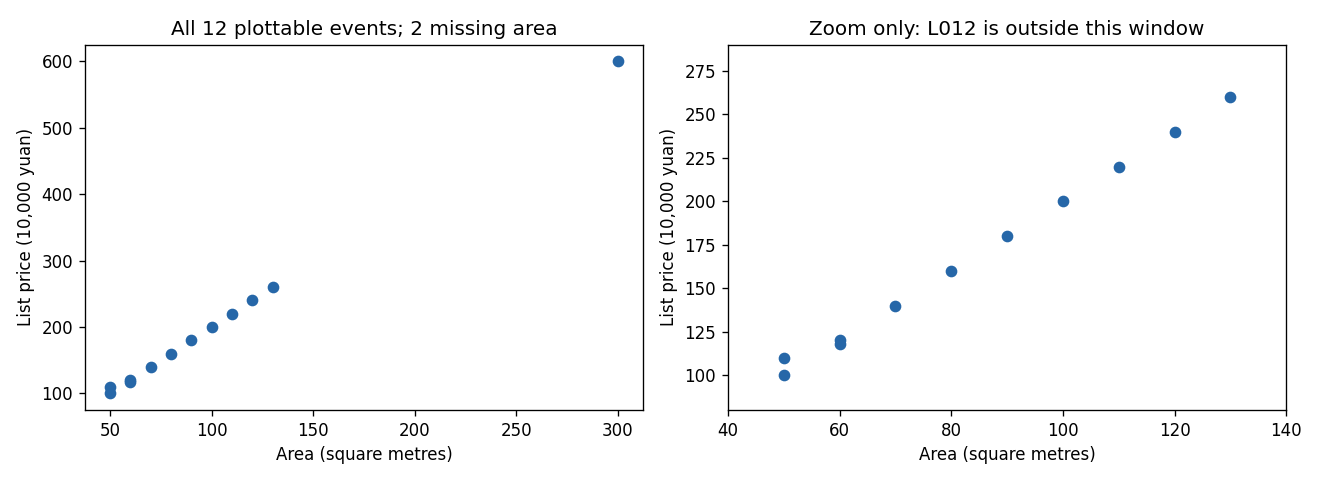

因面积缺失未画 ['L004', 'L010']


In [19]:
scatter_rows = clean.loc[clean.area_sqm.notna() & clean.list_price_wan.notna()].copy()
assert len(scatter_rows) == 12
fig, axes = plt.subplots(1,2,figsize=(11,4))
for ax in axes:
    ax.scatter(scatter_rows.area_sqm.astype(float), scatter_rows.list_price_wan.astype(float), color="#2667A8")
    ax.set(xlabel="Area (square metres)", ylabel="List price (10,000 yuan)")
axes[0].set_title("All 12 plottable events; 2 missing area")
axes[1].set(xlim=(40,140), ylim=(80,290), title="Zoom only: L012 is outside this window")
fig.tight_layout()
image_buffer = BytesIO()
fig.savefig(image_buffer, format="png", dpi=120)
display(NotebookImage(data=image_buffer.getvalue()))
plt.close(fig)
print("因面积缺失未画", clean.loc[clean.area_sqm.isna(), "event_id"].tolist())

## 20 划分清单与训练范围

先用event_id一对一连接固定split清单。训练10次事件、测试4次；此教学划分没有房屋跨组。

In [20]:
splits = pd.read_csv(RAW / "split_manifest.csv", dtype="string")
model_input = clean.merge(splits, on="event_id", how="left", validate="one_to_one", indicator="split_match")
assert model_input.split_match.eq("both").all()
train = model_input.loc[model_input.split.eq("train")].copy()
test = model_input.loc[model_input.split.eq("test")].copy()
assert len(train) == 10 and len(test) == 4
assert not (set(train.property_id) & set(test.property_id))
print("训练/测试事件数", len(train), len(test))
print("训练面积有效数与总和", train.area_sqm.count(), train.area_sqm.sum())

训练/测试事件数 10 4
训练面积有效数与总和 9 670.0


## 21 只学习一个训练均值再应用

L004和L010都用670/9。原始area_sqm保留缺失，新的列才是填补演示。

In [21]:
learned_mean = train.area_sqm.mean()
assert not pd.isna(learned_mean)
model_input["area_was_missing"] = model_input.area_sqm.isna()
model_input["area_imputed_sqm"] = model_input.area_sqm.fillna(learned_mean)
print("训练学得均值", learned_mean)
print("混入测试的反例均值", clean.area_sqm.mean())
display(model_input.loc[model_input.area_was_missing,
                       ["event_id", "split", "area_sqm", "area_imputed_sqm", "area_was_missing"]])
assert np.isclose(learned_mean, 670/9)
assert model_input.area_sqm.isna().sum() == 2
assert np.allclose(model_input.loc[model_input.area_was_missing,"area_imputed_sqm"].astype(float), 670/9)

训练学得均值 74.44444444444444
混入测试的反例均值 101.66666666666667


,event_id,split,area_sqm,area_imputed_sqm,area_was_missing
3,L004,train,<NA>,74.444444,True
9,L010,test,<NA>,74.444444,True


## 22 故意制造错误确认程序拒绝

第一种错误是同一事件价格冲突；第二种是未知数字文本。两者都应该停下来核查，不应变成普通缺失。这里只改内存副本，不触碰原始文件。

In [22]:
from experiment import clean_listings, run, raw_hashes
bad_event = raw.copy()
bad_event.loc[14, "list_price_wan"] = "999"
try:
    clean_listings(bad_event)
except ValueError:
    print("预期通过：同一事件内容冲突被拒绝")
else:
    raise AssertionError("冲突未被拒绝")
bad_number = raw.iloc[:14].copy()
bad_number.loc[0, "area_sqm"] = "fifty"
try:
    clean_listings(bad_number)
except ValueError:
    print("预期通过：未知数字文本被拒绝")
else:
    raise AssertionError("非法数字未被拒绝")

预期通过：同一事件内容冲突被拒绝
预期通过：未知数字文本被拒绝


## 23 完整脚本交叉核验并保存审计

此前各项结果是逐步算出的。现在调用完整流程，与手动步骤比较，同时输出日志和43项测试结果。原始文件摘要值在运行前后必须一致。

In [23]:
hashes_before = raw_hashes()
result = run(ROOT / "outputs")
assert hashes_before == raw_hashes()
pd.testing.assert_frame_equal(clean, result["clean"])
assert np.isclose(result["summary"]["train_area_mean_sqm"], learned_mean)
assert result["summary"]["area_hist_counts"] == counts.tolist()
print("完整脚本状态", result["tests"]["status"])
print("脚本断言数", result["tests"]["test_count"])
print("原始文件保持不变", hashes_before == raw_hashes())
display(result["audit"])
print(json.dumps(result["summary"], ensure_ascii=False, indent=2))

完整脚本状态 passed
脚本断言数 43
原始文件保持不变 True


,step,event_id,source_csv_line,field,before,after,reason
0,exact_duplicate,L003,16,all_original_fields,repeat,removed_from_derived_table,same event and all six original values identical
1,exact_duplicate,L009,17,all_original_fields,repeat,removed_from_derived_table,same event and all six original values identical
2,strip_whitespace,L014,15,district_code,N,N,declared field format excludes surrounding spaces
3,strip_whitespace,L014,15,area_sqm,60,60,declared field format excludes surrounding spaces
4,missing_marker,L004,5,area_sqm,,missing,"declared missing marker, not zero"
5,missing_marker,L010,11,area_sqm,未知,missing,"declared missing marker, not zero"


{
  "raw_rows": 16,
  "clean_events": 14,
  "unique_properties": 12,
  "exact_duplicate_rows_removed": 2,
  "area_observed_count": 12,
  "area_missing_count": 2,
  "price_observed_count": 14,
  "verified_merge_rows": 14,
  "merge_both": 13,
  "merge_left_only": 1,
  "unsafe_merge_rows": 19,
  "unsafe_mean_price_wan": 188.21052631578948,
  "safe_mean_price_wan": 206.28571428571428,
  "safe_price_sum_wan": 2888.0,
  "inner_join_rows": 13,
  "inner_join_mean_price_wan": 176.0,
  "many_to_one_conflict_rejected": true,
  "train_events": 10,
  "test_events": 4,
  "train_observed_area_count": 9,
  "train_area_mean_sqm": 74.44444444444444,
  "all_observed_area_mean_sqm_counterexample": 101.66666666666667,
  "area_hist_counts": [
    5,
    4,
    2,
    0,
    0,
    0,
    1
  ],
  "area_hist_edges": [
    40,
    80,
    120,
    160,
    200,
    240,
    280,
    320
  ],
  "price_quantiles_linear": {
    "0": 100.0,
    "0.25": 125.0,
    "0.5": 180.0,
    "0.75": 235.0,
    "1": 600.0
  

## 24 写出自己的结论

在下一个文字单元填写报告，不要只粘贴一整段输出。至少包含：

1. 一行代表什么，原始记录、事件、房屋分别多少。
2. 去掉了哪些复制，为什么保留复挂牌。
3. 面积与价格的有效分母、S组缺失情况。
4. 合并关系、行数和未匹配身份。
5. 直方图边界、散点图样本量与显示范围。
6. 极端值核查依据、训练填补边界、合成数据限制。

重启内核从头运行后保存。API文档与来源核验见lecture.md和source-checks.json。Anaconda安装、浏览器Jupyter界面未在本包构建环境中测试；本Notebook的真实ipykernel进程内执行输出已保留。

### 我的探索报告

请在这里写下你的报告。图已经在前面的输出中显示，可引用对应单元的结果。不要声称这些合成记录代表真实市场，也不要把散点关联写成因果证明。